# The tool the job postings want couldn't hold my own data

Job descriptions keep naming Power BI and Tableau. So I pointed one at a real project instead of a tutorial dataset: `GrapeExpectations`, a precision-viticulture pipeline of mine that models vine canopy health across 32,978 hex cells (~100 m² each) of Washington State wine country from nine years of Sentinel-2 imagery.

Power BI Service wouldn't take a personal email at signup, and the "free" Microsoft dev-tenant workaround wanted a phone number and a subscription plan on top -- so I moved to Looker Studio, which just needs the Gmail account I already have. That got me past the login wall. It didn't get me past the real one: Looker Studio's map chart draws one marker per row in the browser, and it crashed the tab at 32,978 points. Getting the lat/lon pair into a single field it would even accept as a location took its own detour (a comma inside a comma-delimited value, silently mis-split). These aren't login friction -- they're the tool telling me its native shape is a business dashboard with a few thousand rows and categorical filters, not a science dataset at meter resolution.

So I went back to the process I already had -- Python, matplotlib, the same stack behind everything else in this `drawing/` series -- but not as one-off plotting scripts. I specified a small shared module (`_mapping.py` in the project repo) that encodes the actual decisions a correct version of this visualization needs, and used Claude Code -- CLI, skills, the harness -- to write and iterate the implementation against those decisions. That distinction is the point of this piece: which statistical and design calls got made, by whom, and why, laid out below as they actually happened -- including the ones that were wrong on the first pass and got caught by looking at the output, not assumed correct because code ran without an error.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# The real source of truth is the project repo, not a copy pasted in here --
# importing keeps this notebook honest about which module actually ran.
GRAPE_DIR = Path("../GeoGastronomy/GrapeExpectations/powerbi_dashboard")
sys.path.insert(0, str(GRAPE_DIR))

from _mapping import DELTA_CMAP, NDVI_CMAP, drop_contaminated_dates, masked_triangulation, to_local_meters

cells = pd.read_csv(GRAPE_DIR / "dim_cells.csv")
print(f"{len(cells):,} hex cells, ~100 m² each -- this is the grid Looker Studio's map chart crashed on")

32,978 hex cells, ~100 m² each -- this is the grid Looker Studio's map chart crashed on


## The semantic layer: decisions, not just a plotting library

`_mapping.py` is three things, each one a call I made and had implemented against, not a default:

1. **Triangle masking.** The vineyard is several disconnected blocks, not one contiguous field. A naive `tricontourf` triangulates across the *entire* convex hull of the input points -- it will happily interpolate a smooth color gradient through the empty land between two separate blocks that have no cells in it at all. First render of the build-up map below had exactly this: long triangular streaks and a phantom dark blob where two blocks' bounding hull overlapped nothing. `masked_triangulation()` drops any triangle whose longest edge is more than 3x the typical cell-to-cell spacing, so only real, contiguous vineyard gets colored.
2. **Sequential vs. diverging, tied to what the number actually is.** Absolute NDVI (`NDVI_CMAP`, tan→green) is a magnitude -- more green is unambiguously more canopy. A *delta* between two dates (`DELTA_CMAP`, red↔gray↔blue) is a polarity around zero -- some cells really do read lower at the "peak" date than at the season's low point, not from noise. The first build of the peak-minus-start map below reused the magnitude ramp for a signed delta; declining cells rendered tan, which reads as "bare ground" in the companion GIF's color language. Same numbers, wrong chart form for what they mean -- caught by looking at the image, not by any type system.
3. **A shared peak/trough date, not a per-cell argmax.** "Peak NDVI" sounds like `max()` per cell. Taking each cell's own independent maximum across ~40 satellite dates let neighboring cells land on *different* dates purely from per-date measurement noise, which inflated cell-to-cell variance with noise instead of signal -- confirmed visually, the first version was badly speckled. The fix: one shared date -- whichever date the *vineyard as a whole* was greenest -- applied to every cell. Also just the more literal reading of "peak" as a point in the season, not a per-pixel cherry-pick.

One more catch that isn't a plotting decision at all: the contamination filter below exists because three 2024 satellite dates dip sharply and fully recover the very next date -- cloud/shadow contamination in a single composite, not real vegetation change. It only drops a date if it dips below *both* neighbors, so a genuine multi-date decline (autumn senescence into dormancy) is protected.

In [2]:
DATA = GRAPE_DIR.parent / "RegressionRidge" / "data"

daily = pd.read_csv(DATA / "ndvi" / "tiles_100m2" / "ndvi_100m2_2024.csv")
daily = daily.groupby(["tile_id", "date"], as_index=False)["ndvi"].mean()
daily, _ = drop_contaminated_dates(daily)

  dropping 2024-07-25: mean ndvi 0.201 vs neighbors 0.428/0.435 -- looks cloud-contaminated
  dropping 2024-09-05: mean ndvi 0.314 vs neighbors 0.427/0.466 -- looks cloud-contaminated
  dropping 2024-10-03: mean ndvi 0.306 vs neighbors 0.429/0.438 -- looks cloud-contaminated


## Piece 1: build-up, bud break to peak

"Start of grow" isn't the calendar's January 1 either -- the literal first satellite date of the year overlaps winter cover-crop and soil-moisture greenness with actual vine dormancy, which undersells how much the vines themselves built up. "Start" here is the pre-green-up trough: the lowest-mean-NDVI date among everything before the peak, found from the data rather than hardcoded, so the same logic still finds the right point against a different year or vineyard.

In [3]:
HARVEST_WINDOW_START = "2024-09-02"  # ISO week 36 -- the harvest-window convention already used in the ML pipeline
HARVEST_WINDOW_END = "2024-10-27"    # ISO week 43 end

pre_harvest = daily[daily["date"] < HARVEST_WINDOW_START]
peak_date = pre_harvest.groupby("date")["ndvi"].mean().idxmax()
peak = pre_harvest[pre_harvest["date"] == peak_date].set_index("tile_id")["ndvi"]

pre_peak = daily[daily["date"] < peak_date]
start_date = pre_peak.groupby("date")["ndvi"].mean().idxmin()
start = pre_peak[pre_peak["date"] == start_date].set_index("tile_id")["ndvi"]

buildup = (peak - start).rename("ndvi_buildup")
print(f"start (pre-green-up trough): {start_date} | peak: {peak_date}")
print(f"buildup -- mean {buildup.mean():.3f}, min {buildup.min():.3f}, max {buildup.max():.3f}")

start (pre-green-up trough): 2024-05-03 | peak: 2024-06-25
buildup -- mean 0.218, min -0.310, max 0.565


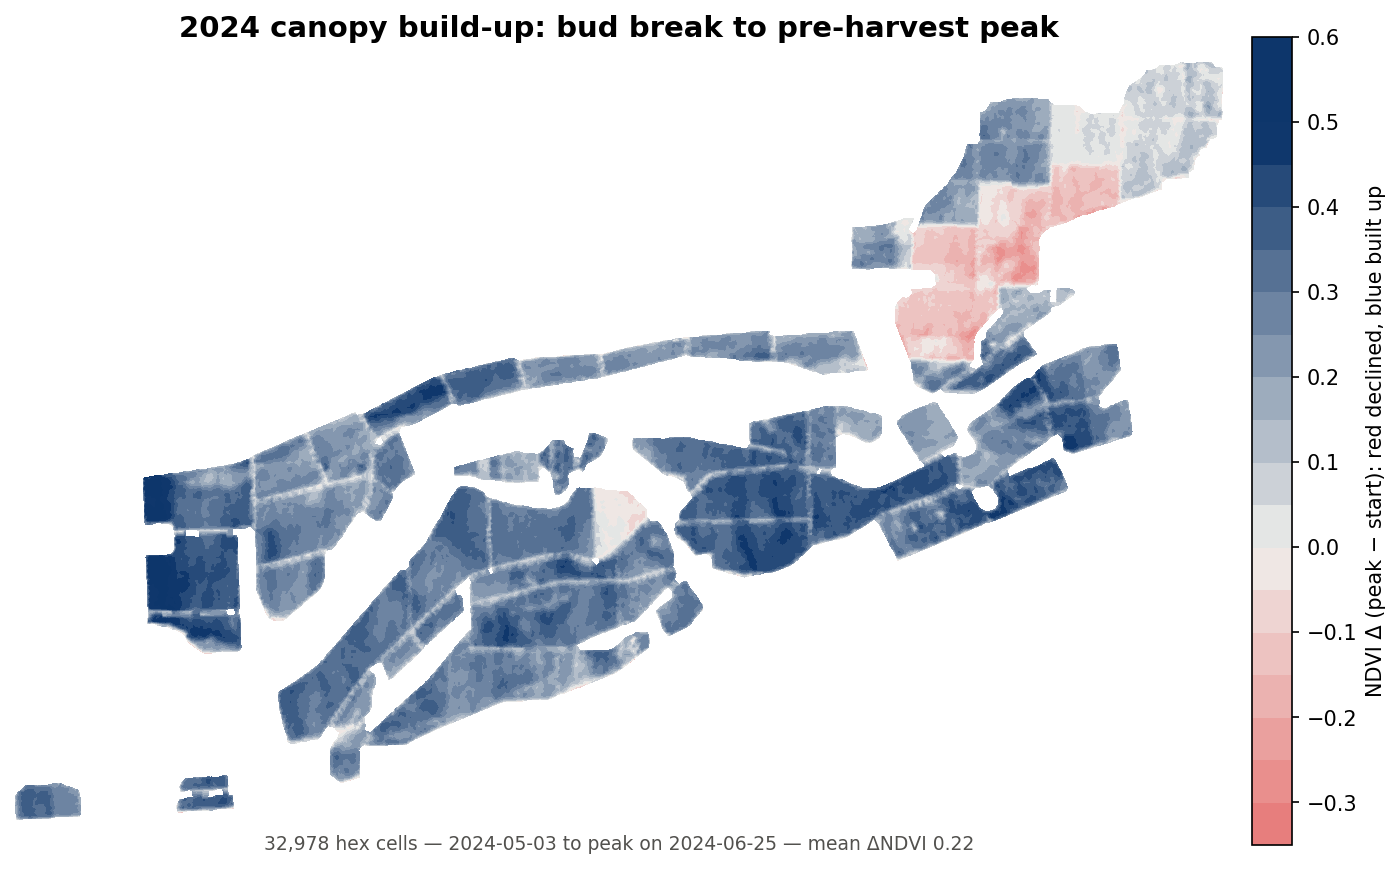

In [4]:
df = cells.merge(buildup, on="tile_id", how="left")
x, y = to_local_meters(df["lon"].to_numpy(), df["lat"].to_numpy())
triang = masked_triangulation(x, y)

fig, ax = plt.subplots(figsize=(10, 8), dpi=150)
span = max(abs(df["ndvi_buildup"].quantile(0.01)), abs(df["ndvi_buildup"].quantile(0.99)))
contour = ax.tricontourf(triang, df["ndvi_buildup"], levels=20, cmap=DELTA_CMAP,
                          vmin=-span, vmax=span)
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
cbar = fig.colorbar(contour, ax=ax, shrink=0.7, pad=0.02)
cbar.set_label("NDVI Δ (peak − start): red declined, blue built up", fontsize=10)
ax.set_title("2024 canopy build-up: bud break to pre-harvest peak", fontsize=14, weight="bold", pad=12)
ax.text(0.5, -0.04,
        f"{len(df):,} hex cells — {start_date} to peak on {peak_date} — mean ΔNDVI {buildup.mean():.2f}",
        transform=ax.transAxes, ha="center", fontsize=9, color="#52514e")
fig.tight_layout()
fig.savefig("canopy_semantic_layer_buildup.png", bbox_inches="tight", facecolor="white")
plt.show()

## Piece 2: decline, peak to harvest

Grapes aren't corn. A widespread decline here isn't necessarily a problem to explain away -- wine growers routinely cut back irrigation after veraison on purpose, trading canopy vigor for concentrated sugar and flavor in the fruit. "Harvest" mirrors the peak's logic into the harvest window itself (ISO weeks 36-43): the single date with the *lowest* vineyard-wide mean NDVI within that window, the furthest point into decline actually observed during picking.

In [5]:
harvest_window = daily[(daily["date"] >= HARVEST_WINDOW_START) & (daily["date"] <= HARVEST_WINDOW_END)]
harvest_date = harvest_window.groupby("date")["ndvi"].mean().idxmin()
harvest = harvest_window[harvest_window["date"] == harvest_date].set_index("tile_id")["ndvi"]

decline = (harvest - peak).rename("ndvi_decline")
print(f"peak: {peak_date} | harvest: {harvest_date}")
print(f"decline -- mean {decline.mean():.3f}, min {decline.min():.3f}, max {decline.max():.3f}")

peak: 2024-06-25 | harvest: 2024-10-08
decline -- mean -0.070, min -0.538, max 0.401


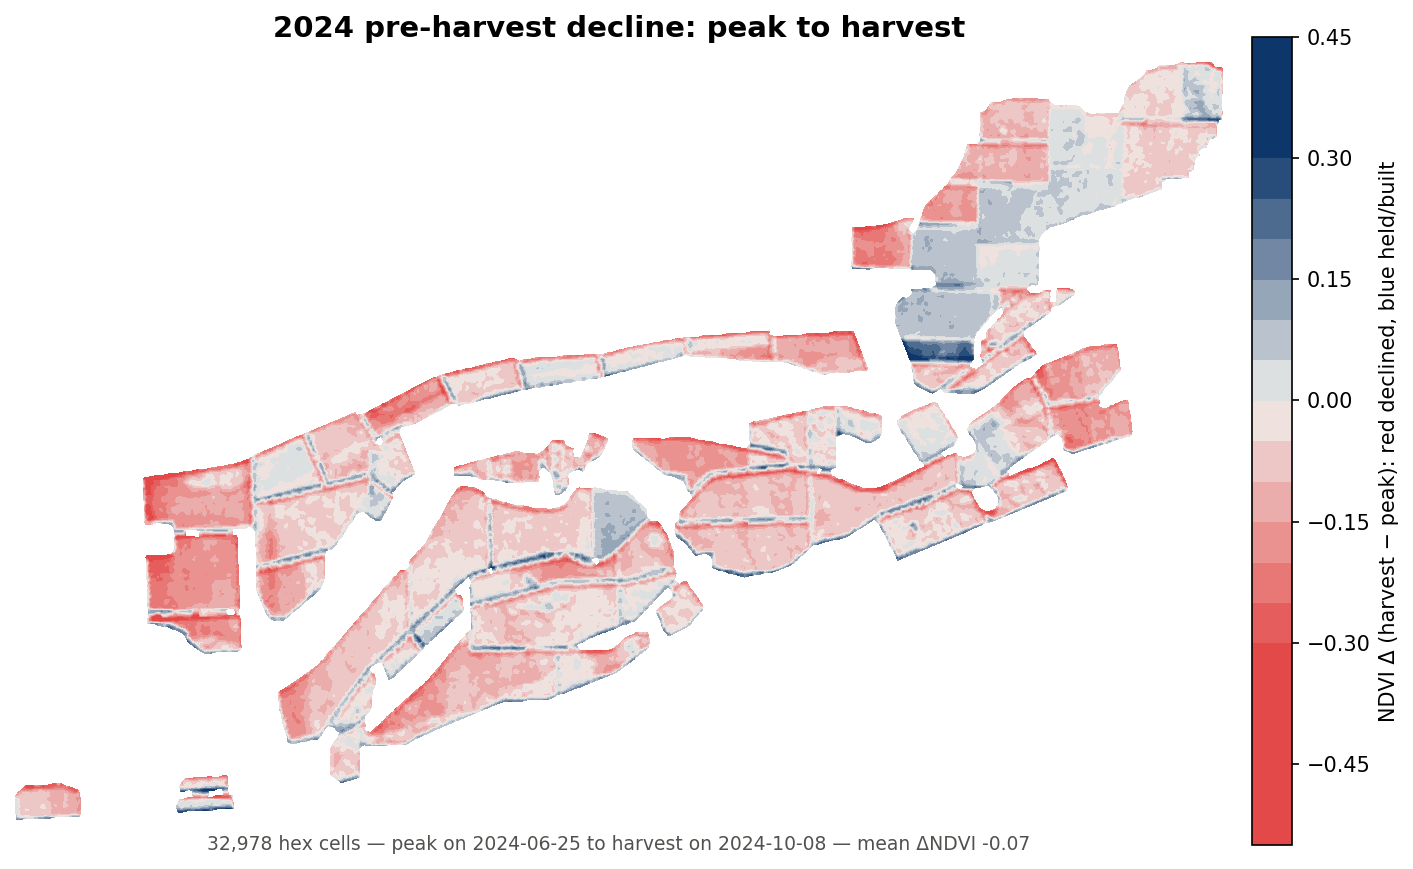

In [6]:
df2 = cells.merge(decline, on="tile_id", how="left")
x2, y2 = to_local_meters(df2["lon"].to_numpy(), df2["lat"].to_numpy())
triang2 = masked_triangulation(x2, y2)

fig, ax = plt.subplots(figsize=(10, 8), dpi=150)
span2 = max(abs(df2["ndvi_decline"].quantile(0.01)), abs(df2["ndvi_decline"].quantile(0.99)))
contour = ax.tricontourf(triang2, df2["ndvi_decline"], levels=20, cmap=DELTA_CMAP,
                          vmin=-span2, vmax=span2)
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
cbar = fig.colorbar(contour, ax=ax, shrink=0.7, pad=0.02)
cbar.set_label("NDVI Δ (harvest − peak): red declined, blue held/built", fontsize=10)
ax.set_title("2024 pre-harvest decline: peak to harvest", fontsize=14, weight="bold", pad=12)
ax.text(0.5, -0.04,
        f"{len(df2):,} hex cells — peak on {peak_date} to harvest on {harvest_date} — mean ΔNDVI {decline.mean():.2f}",
        transform=ax.transAxes, ha="center", fontsize=9, color="#52514e")
fig.tight_layout()
fig.savefig("canopy_semantic_layer_decline.png", bbox_inches="tight", facecolor="white")
plt.show()

## Self-check: is the same block showing up twice, or is that a coincidence?

Eyeballing both PNGs, one block in the northeast reads as the outlier in both -- weak build-up in piece 1, and the one place that held or kept building instead of declining in piece 2. That's a specific, falsifiable claim (low build-up correlates with less decline, cell for cell), not just "these two maps look similar" -- check it directly before stating it.

In [7]:
both = buildup.rename("buildup").to_frame().join(decline.rename("decline"))
corr = both["buildup"].corr(both["decline"])
print(f"Pearson r(buildup, decline) = {corr:.3f} across {len(both):,} cells")
assert corr < 0, "expected a negative correlation (low build-up -> less decline) -- claim doesn't hold, don't post it"
print("self-check passed: cells that built up less through summer also declined less toward harvest -- the same pattern, not a coincidence of two separate maps")

Pearson r(buildup, decline) = -0.606 across 32,978 cells
self-check passed: cells that built up less through summer also declined less toward harvest -- the same pattern, not a coincidence of two separate maps


## Piece 3: the season, frame by frame

The two static maps are both a difference of two dates. This is the whole shape in between -- every real Sentinel-2 composite date for 2024, not an evenly-spaced fake calendar, with the color scale fixed across every frame so the animation can't lie about magnitude (a per-frame autoscale would make a dim early-spring frame look just as green as peak summer). Frames render to in-memory PNGs and get stitched with Pillow directly -- `FuncAnimation` + `PillowWriter` throws a frame-buffer error on this machine's older matplotlib, so that's the one place the "semantic layer" framing above doesn't quite cover: not every fix here is a statistical decision, some are just this environment's matplotlib being a few years old.

In [8]:
import io
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from PIL import Image

tile_order = cells["tile_id"].to_numpy()
dates = sorted(daily["date"].unique())
vmin, vmax = daily["ndvi"].quantile([0.01, 0.99])
norm = Normalize(vmin=vmin, vmax=vmax)

x3, y3 = to_local_meters(cells["lon"].to_numpy(), cells["lat"].to_numpy())
triang3 = masked_triangulation(x3, y3)

def frame_values(date):
    day = daily[daily["date"] == date].set_index("tile_id")["ndvi"]
    return day.reindex(tile_order).to_numpy()

fig, ax = plt.subplots(figsize=(8, 6.5), dpi=100)
fig.colorbar(ScalarMappable(norm=norm, cmap=NDVI_CMAP), ax=ax, shrink=0.7, pad=0.02).set_label("NDVI")

frames = []
for date in dates:
    ax.clear()
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tricontourf(triang3, frame_values(date), levels=20, cmap=NDVI_CMAP, norm=norm)
    ax.set_title(f"Vineyard NDVI — {date}", fontsize=13, weight="bold")
    buf = io.BytesIO()
    fig.savefig(buf, format="png", facecolor="white")
    buf.seek(0)
    frames.append(Image.open(buf).convert("RGB"))
plt.close(fig)

frames[0].save("canopy_semantic_layer_season.gif", save_all=True, append_images=frames[1:], duration=200, loop=0)
print(f"{len(frames)} frames -> canopy_semantic_layer_season.gif")

54 frames -> canopy_semantic_layer_season.gif


## Source & caption notes

- Data: `GrapeExpectations`' own v2 pipeline output (Sentinel-2 NDVI via Google Earth Engine, 32,978 hex cells at ~100 m² resolution, 2024 season). `dim_cells.csv` and the raw per-date NDVI CSVs are read directly from that project repo, not copied in.
- `ML/clusters.csv` in that repo is a known-stale artifact from an older, coarser 3,598-cell grid and is deliberately not used anywhere in this piece -- see that project's `CONTEXT.md` for the full story.
- Three deliberate departures from a default matplotlib approach, all explained inline above: triangle-masked `tricontourf` (not a naive fill), diverging vs. sequential color tied to whether the number is a signed delta or a magnitude, and a shared peak/trough date instead of a per-cell argmax.
- The framing point of this piece: Power BI and Tableau get named in job postings because they're the fast path to a business dashboard over a few thousand rows. They're not built for a meter-resolution science dataset, and hitting that ceiling isn't a skill gap -- it's information about which tool fits which job. The actual capability on display here is the same one behind the rest of this `drawing/` series: specifying what a correct visualization has to encode, catching it when a first pass gets that wrong, and using Claude Code as the hands that implement the spec, not the author of it.